# Integrate an sbi NRE (ONNX)

This tutorial mirrors the structure of `bayesflow_lre_integration.ipynb` for the
third major SBI library in the HSSM ecosystem: **[sbi](https://github.com/sbi-dev/sbi)**
(mackelab). It demonstrates how to:

1. Train a neural ratio estimator (NRE) on synthetic DDM simulations using sbi.
2. Export the trained estimator to ONNX via
   [`lanfactory.onnx.transform_sbi_to_onnx`](https://lnccbrown.github.io/LANfactory/exporting_sbi_models/).
3. Load the ONNX file into HSSM exactly like any other LAN-style approximator and run
   MCMC inference.
4. Compare numerically against HSSM's analytical DDM posterior as a reference.

> **Why NRE only, not NLE/MNLE?**
> Vanilla NLE with a MAF flow misbehaves on DDM data because rt is continuous but
> choice is discrete (∈ {−1, +1}). The flow treats choice as continuous, can't
> represent the support boundary `rt > t_nd`, and produces qualitatively wrong
> posteriors (we observed v ≈ 0.12 vs truth 0.5, with spurious bimodality on a).
> The correct sbi method is **MNLE** (Mixed Neural Likelihood Estimator), which
> splits x into discrete and continuous dims and models each properly. But MNLE's
> categorical lookup uses `torch.searchsorted`, which `torch.onnx.export` doesn't
> support and `jaxonnxruntime` lacks a handler for — a ~50-line upstream PR adding
> a `SearchSorted` handler to `jaxonnxruntime` would unlock both MNLE and NSF
> flows in one stroke.
>
> Until then, **NRE is an export-compatible integration path** — it does not model
> a continuous density, but learns a classifier between joint and marginal pairs.
> This notebook hard-gates sensitivity, export fidelity, and sampler health, then
> reports posterior agreement with the analytical reference as a diagnostic. A
> failing agreement result means this baseline is **not fidelity-qualified for
> scientific or production inference**; it remains useful only as an integration
> demonstration.

> **Environment note:** This tutorial requires both `hssm` and `lanfactory[all]` (which
> pulls `sbi` and `nflows`) in the same environment. JAX/flax/numpyro pins must be
> resolved jointly across the two packages.

For the map of all external-trainer routes, see [Bring your own likelihood](https://lnccbrown.github.io/HSSM/how_to/external_trainers/); the rules the exported file must satisfy are in [The ONNX likelihood contract](https://lnccbrown.github.io/HSSM/how_to/custom_onnx_likelihoods/).

## Part 1 — Setup

In [1]:
# Enable x64 BEFORE any other JAX-touching import. sbi-exported ONNX graphs carry
# int64 shape/index tensors (typical for torch.onnx.export of normalizing flows);
# HSSM's ONNX-likelihood path relies on JAX x64 so those values are preserved
# exactly. x64 is also enabled automatically by `import hssm` (pytensor sets it
# from the default floatX="float64"); setting it explicitly here keeps the
# notebook self-contained and import-order-independent.
import jax

jax.config.update("jax_enable_x64", True)

import warnings
from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

# lanfactory>=0.7.0 ships the sbi exporter; HSSM's `notebook` dependency group
# pins it (alongside sbi / nflows), so the import is direct.
from lanfactory.onnx import transform_sbi_to_onnx
from sbi.inference import NRE_A
from sbi.neural_nets import classifier_nn
from sbi.utils import BoxUniform
from ssms.basic_simulators.simulator import simulator
from torch import nn

import hssm

OBSERVED_DATA_SEED = 11
TRAINING_DATA_SEED = 23
NRE_SAMPLING_SEED = 101
ANALYTICAL_SAMPLING_SEED = 102

np.random.seed(TRAINING_DATA_SEED)
torch.manual_seed(TRAINING_DATA_SEED)

# Training budget for the export-compatible NRE_A baseline: 1M (theta, x)
# pairs from ssm-simulators (1 sample per theta) at the wider HSSM-default prior
# bounds, with a moderate-sized MLP classifier. Part 3 explains why this baseline
# is used rather than NRE_B / FCEmbedding / atomic contrastive.
N_TRAIN = 1_000_000
N_OBS = 500
NUM_EPOCHS = 300
STOP_AFTER_EPOCHS = 50
TRAINING_BATCH_SIZE = 500
HIDDEN_FEATURES = 100
# The NRE fit keeps a bounded 500 retained draws per chain. The cheaper analytical
# reference retains 1,000 draws per chain to stabilize split-R-hat at the same
# MAX_R_HAT threshold; this is a reference-budget increase, not threshold relaxation.
MCMC_DRAWS = 500
ANALYTICAL_MCMC_DRAWS = 1_000
MCMC_TUNE = 500
MCMC_CHAINS = 4
MAX_TREE_DEPTH = 8
MAX_R_HAT = 1.01
MIN_ESS = 400
MIN_BFMI = 0.30
MIN_SWEEP_RANGE = 10
MAX_EXPORT_DELTA = 1e-4
MAX_STANDARDIZED_MEAN_GAP = 1.5
MIN_SD_RATIO = 0.5
MAX_SD_RATIO = 2.0


def report_captured_warnings(label, captured_warnings):
    """Print warning messages without machine-specific source paths."""
    if captured_warnings:
        print(f"{label} warnings:")
        for captured_warning in captured_warnings:
            print(f"- {captured_warning.message}")

mlflow not available


mlflow not available


## Part 2 — Simulate observed DDM data

We use the standard 4-parameter DDM (`v`, `a`, `z`, `t`) from `ssm-simulators`. The
two tutorials share only `TRUE_THETA`. This sbi example uses 500 observed trials,
infers all four DDM parameters, uses separate deterministic data and sampling seeds,
and trains under broader prior ranges. The [BayesFlow NRE tutorial](../bayesflow_nre_onnx_integration/)
uses 100 observations, fixes `a`, `z`, and `t`, and trains under narrower priors, so
the two posterior checks are complementary integration examples rather than matched experiments.

In [2]:
DDM_PARAM_NAMES = ["v", "a", "z", "t"]
# The NRE is trained on this rectangular domain. Both HSSM fits below receive
# the same bounds and Uniform priors, so neither posterior can leave the
# classifier's training support.
PRIOR_LOW = np.array([-3.0, 0.3, 0.0, 0.0], dtype=np.float32)
PRIOR_HIGH = np.array([3.0, 2.5, 1.0, 2.0], dtype=np.float32)
TRUE_THETA = np.array([0.5, 1.2, 0.5, 0.25], dtype=np.float32)
COMPARISON_BOUNDS = {
    name: (float(lower), float(upper))
    for name, lower, upper in zip(DDM_PARAM_NAMES, PRIOR_LOW, PRIOR_HIGH)
}
COMPARISON_PRIORS = {
    name: {"name": "Uniform", "lower": lower, "upper": upper}
    for name, (lower, upper) in COMPARISON_BOUNDS.items()
}
COMPARISON_MODEL_CONFIG = {
    "bounds": COMPARISON_BOUNDS,
    "default_priors": COMPARISON_PRIORS,
}

out = simulator(
    theta=TRUE_THETA[None, :],
    model="ddm",
    n_samples=N_OBS,
    random_state=OBSERVED_DATA_SEED,
)
obs_data = pd.DataFrame(
    {
        "rt": out["rts"].squeeze().astype(np.float32),
        "response": out["choices"].squeeze().astype(np.float32),
    }
)
print(f"observed: {len(obs_data)} trials at true theta = {TRUE_THETA}")
obs_data.head()

observed: 500 trials at true theta = [0.5  1.2  0.5  0.25]


,rt,response
0,0.833728,1.0
1,1.076240,1.0
2,0.602408,1.0
3,2.786506,1.0
4,0.597780,1.0


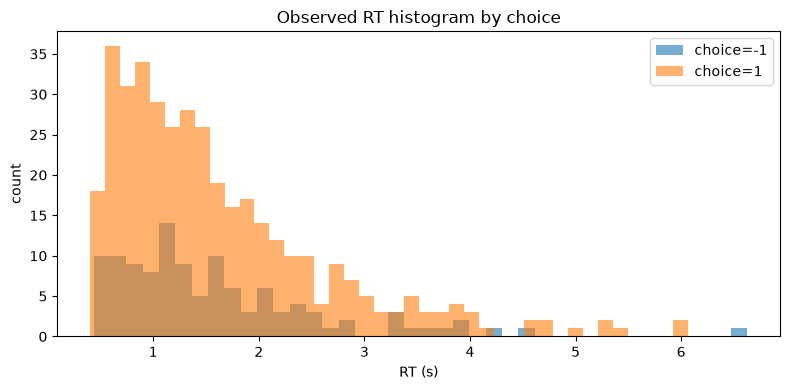

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
for resp, color in zip([-1, 1], ["C0", "C1"]):
    mask = obs_data["response"] == resp
    ax.hist(
        obs_data.loc[mask, "rt"],
        bins=40,
        alpha=0.6,
        label=f"choice={int(resp)}",
        color=color,
    )
ax.set_xlabel("RT (s)")
ax.set_ylabel("count")
ax.set_title("Observed RT histogram by choice")
ax.legend()
plt.tight_layout()
plt.show()

## Part 3 — Train an sbi NRE_A classifier on DDM simulations

`NRE_A` (Hermans et al. 2020) learns a binary classifier that distinguishes
joint `(θ, x)` pairs from marginal `(θ', x)` pairs (where θ' is drawn from the
prior). The output logit equals `log p(x | θ) − log p(x)` up to a constant, so
it serves directly as the HSSM log-likelihood for MCMC (the θ-independent
constant drops out under MCMC's accept ratios).

This tutorial uses an export-compatible NRE baseline:

- `NRE_A` (binary classifier, not contrastive)
- 1M `(θ, x)` training pairs (1 sample per θ)
- `hidden_features = 100` (sbi default is 50)
- No embedding net on θ
- `norm_layer = nn.Identity` (jaxonnxruntime doesn't implement
  `LayerNormalization`, so the MLP norm layer is disabled)

We keep this baseline because a more ambitious configuration (NRE_B + atomic
contrastive + multi-sample-per-θ + FCEmbedding + `hidden_features=128`) gave HSSM
a near-constant log-likelihood at MCMC time — the chains explored the entire
prior with no concentration. This simpler configuration is a concrete ONNX-compatible
starting point. The hard checks below establish that the integration is operational;
the analytical comparison separately reports whether this baseline meets the
tutorial's illustrative location and scale criteria.

In [4]:
prior = BoxUniform(
    low=torch.from_numpy(PRIOR_LOW),
    high=torch.from_numpy(PRIOR_HIGH),
)
theta_train = prior.sample((N_TRAIN,))

# Batched ssm-simulators: theta of shape (N, 4) with n_samples=1 returns
# rts/choices of shape (N, 1). Much faster than a Python loop for large N.
sim = simulator(
    theta=theta_train.numpy().astype(np.float32),
    model="ddm",
    n_samples=1,
    random_state=TRAINING_DATA_SEED,
)
x_train = torch.from_numpy(
    np.stack([sim["rts"].squeeze(-1), sim["choices"].squeeze(-1)], axis=-1).astype(
        np.float32
    )
)
print(f"training set: theta={theta_train.shape}, x={x_train.shape}")

training set: theta=torch.Size([1000000, 4]), x=torch.Size([1000000, 2])


In [5]:
# Build the classifier. LayerNorm is disabled because jaxonnxruntime
# doesn't implement LayerNormalization. No embedding net on theta in this
# baseline-revert iteration (see Part 3 markdown for the bisect context).
with warnings.catch_warnings(record=True) as training_warnings:
    warnings.simplefilter("always")
    classifier_builder = classifier_nn(
        model="mlp",
        norm_layer=nn.Identity,
        hidden_features=HIDDEN_FEATURES,
    )
    inference_nre = NRE_A(prior=prior, classifier=classifier_builder)
    classifier_nre = inference_nre.append_simulations(theta_train, x_train).train(
        training_batch_size=TRAINING_BATCH_SIZE,
        max_num_epochs=NUM_EPOCHS,
        stop_after_epochs=STOP_AFTER_EPOCHS,
    )
report_captured_warnings("sbi training", training_warnings)
classifier_nre.eval()
print("NRE_A training complete")

 Training neural network. Epochs trained: 1

 Training neural network. Epochs trained: 2

 Training neural network. Epochs trained: 3

 Training neural network. Epochs trained: 4

 Training neural network. Epochs trained: 5

...

 Training neural network. Epochs trained: 155

 Training neural network. Epochs trained: 156

 Training neural network. Epochs trained: 157

 Training neural network. Epochs trained: 158

 Neural network successfully converged after 159 epochs.sbi training warnings:
- Unknown kwargs passed to ClassifierConfig: {'norm_layer'}. These will be forwarded to the underlying builder. If this is unintentional, check for typos.
- Data has extreme outliers in dimension(s) [0] (beyond 10.0x IQR from quartiles). This may cause precision loss during z-scoring, where distinct values become indistinguishable. Consider removing outliers from your data or setting `z_score_x='none'` (though this may affect training).
NRE_A training complete


## Part 4 — Export the trained NRE to ONNX

The exporter wraps the classifier's `forward(theta, x)` logit as the HSSM
log-likelihood. No Jacobian correction is needed — ratios are invariant to the
z-score standardization sbi applies internally.

In [6]:
# User-configurable: where the .onnx file lands. Default is outside the HSSM
# repo so notebook re-runs don't pollute the working tree.
# Override examples:
#   ARTIFACT_DIR = Path("/path/to/my/project/onnx")          # keep nearby
#   ARTIFACT_DIR = Path(tempfile.mkdtemp())                  # ephemeral
ARTIFACT_DIR = Path.home() / "sbi_onnx_tutorial"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
nre_onnx_path = ARTIFACT_DIR / "ddm_nre.onnx"

with warnings.catch_warnings(record=True) as export_warnings:
    warnings.simplefilter("always")
    transform_sbi_to_onnx(
        classifier_nre,
        str(nre_onnx_path),
        mode="nre",
        example_theta_dim=4,
        example_x_dim=2,
    )
report_captured_warnings("ONNX export", export_warnings)
print(f"exported NRE: {nre_onnx_path.name} ({nre_onnx_path.stat().st_size:,} bytes)")

ONNX export warnings:
- You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
- The feature will be removed. Please remove usage of this function
- Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
- Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
- Converting a tensor to a Python boolean mi

## Part 4b — Pre-MCMC verification: is the classifier sensitive and faithfully exported?

Before paying the multi-minute MCMC cost, sanity-check two things:

1. **Logit sweep across θ-space.** Hold three θ dimensions at their true values
   and sweep the fourth across its prior range, plotting the summed classifier
   log-ratio on the observed data. Substantial vertical range shows that the
   classifier is sensitive to that parameter. Every dimension must span at
   least `MIN_SWEEP_RANGE` logit units. This is a sensitivity/non-collapse
   check, not evidence of posterior calibration.

2. **ONNX export round-trip.** Compare `classifier_nre(theta, x).item()` to the
   exported ONNX file evaluated through `onnxruntime` on the same input. If
   they disagree, the export has introduced a bug and MCMC won't be running
   the model you think it is.

These cells use the in-memory `classifier_nre` from Part 3 and the exported
file from Part 4 — they're cheap, no MCMC required.

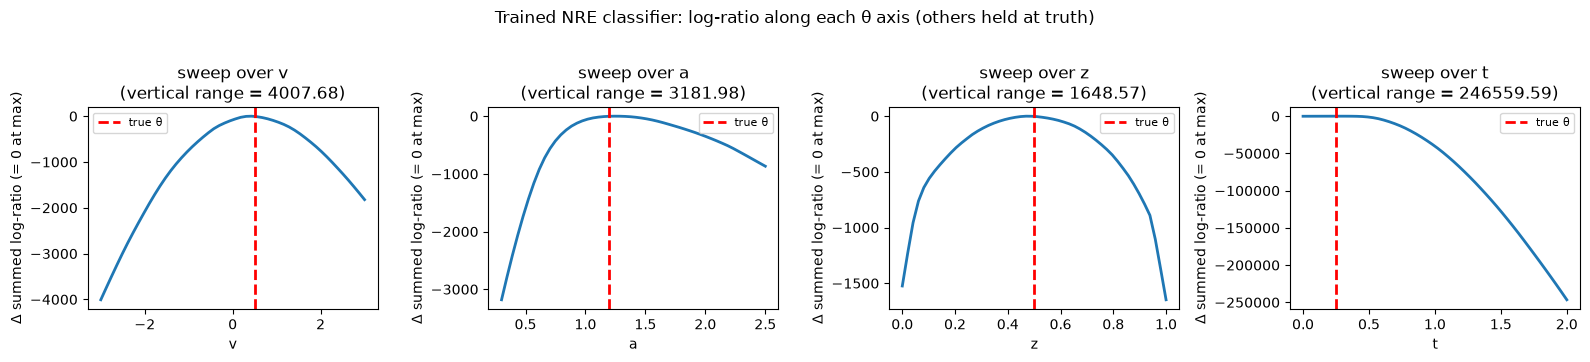


Per-dim vertical range (max log-ratio − min log-ratio):
  v: 4007.68
  a: 3181.98
  z: 1648.57
  t: 246559.59
All parameter sweeps span at least 10.0 logit units.
This establishes sensitivity/non-collapse, not posterior calibration.


In [7]:
# Diagnostic: how much does the NRE logit change as we sweep each theta dim?
sweep_pts = 50
sweep_results = {}
obs_x_t = torch.from_numpy(obs_data[["rt", "response"]].values.astype(np.float32))
theta_center = torch.tensor(TRUE_THETA, dtype=torch.float32)
for dim, name in enumerate(DDM_PARAM_NAMES):
    sweep = torch.linspace(PRIOR_LOW[dim], PRIOR_HIGH[dim], sweep_pts)
    logits = []
    for v in sweep:
        theta = theta_center.clone()
        theta[dim] = v
        theta_row = theta.unsqueeze(0).repeat(len(obs_x_t), 1)
        with torch.no_grad():
            logits.append(classifier_nre(theta_row, obs_x_t).sum().item())
    sweep_results[name] = (sweep.numpy(), np.array(logits))

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, name in zip(axes, DDM_PARAM_NAMES):
    th, lp = sweep_results[name]
    ax.plot(th, lp - lp.max(), "C0-", linewidth=2)
    ax.axvline(
        TRUE_THETA[DDM_PARAM_NAMES.index(name)],
        color="red",
        linestyle="--",
        linewidth=2,
        label="true θ",
    )
    ax.set_xlabel(name)
    ax.set_ylabel("Δ summed log-ratio (= 0 at max)")
    ax.set_title(f"sweep over {name}\n(vertical range = {np.ptp(lp):.2f})")
    ax.legend(fontsize=8)
fig.suptitle(
    "Trained NRE classifier: log-ratio along each θ axis (others held at truth)",
    y=1.02,
)
plt.tight_layout()
plt.show()

sweep_ranges = {
    name: float(np.ptp(logits)) for name, (_, logits) in sweep_results.items()
}
failed_sweeps = {
    name: value
    for name, value in sweep_ranges.items()
    if not np.isfinite(value) or value < MIN_SWEEP_RANGE
}

# Report and enforce sensitivity in every inferred parameter dimension.
print("\nPer-dim vertical range (max log-ratio − min log-ratio):")
for name in DDM_PARAM_NAMES:
    print(f"  {name}: {sweep_ranges[name]:.2f}")
assert not failed_sweeps, (
    f"NRE sensitivity check failed (required >= {MIN_SWEEP_RANGE:.1f}): {failed_sweeps}"
)
print(f"All parameter sweeps span at least {MIN_SWEEP_RANGE:.1f} logit units.")
print("This establishes sensitivity/non-collapse, not posterior calibration.")

In [8]:
# Diagnostic: does the exported ONNX match the torch classifier?
import onnxruntime as _ort

_sess = _ort.InferenceSession(str(nre_onnx_path))
_input_name = _sess.get_inputs()[0].name
_test_theta = torch.tensor([[0.5, 1.2, 0.5, 0.25]], dtype=torch.float32)
_test_x = torch.tensor([[0.5, 1.0]], dtype=torch.float32)
_combined = (
    torch.cat([_test_theta, _test_x], dim=-1).squeeze(0).numpy().astype(np.float32)
)

with torch.no_grad():
    _y_torch = float(classifier_nre(_test_theta, _test_x).item())
_y_ort = float(_sess.run(None, {_input_name: _combined})[0])

print(f"torch logit at (θ=true, x=(0.5, +1)):  {_y_torch:+.5f}")
print(f"ORT logit at (θ=true, x=(0.5, +1)):    {_y_ort:+.5f}")
_export_delta = abs(_y_torch - _y_ort)
print(f"|Δ|: {_export_delta:.2e}")
assert np.isfinite(_export_delta) and _export_delta <= MAX_EXPORT_DELTA, (
    "ONNX export disagrees with the torch classifier: "
    f"|Δ|={_export_delta:.2e} > {MAX_EXPORT_DELTA:.1e}"
)
print("Export round-trip passed; posterior agreement is reported below.")

torch logit at (θ=true, x=(0.5, +1)):  +1.03017
ORT logit at (θ=true, x=(0.5, +1)):    +1.03017
|Δ|: 1.19e-07
Export round-trip passed; posterior agreement is reported below.


2026-08-28 07:12:23.373663303 [W:onnxruntime:Default, device_discovery.cc:146 GetPciBusId] Skipping pci_bus_id for PCI path at "/sys/devices/LNXSYSTM:00/LNXSYBUS:00/ACPI0004:00/MSFT1000:00/5620e0c7-8062-4dce-aeb7-520c7ef76171" because filename "5620e0c7-8062-4dce-aeb7-520c7ef76171" did not match expected pattern of [0-9a-f]+:[0-9a-f]+:[0-9a-f]+[.][0-9a-f]+


## Part 5 — High-level integration via `hssm.HSSM()`

HSSM's `loglik_kind="approx_differentiable"` path consumes the `.onnx` file
identically to a LAN-trained network. With `model="ddm"` HSSM already knows the
parameter list and response columns; we just hand it the file.

In [9]:
model_nre = hssm.HSSM(
    data=obs_data,
    model="ddm",
    model_config=COMPARISON_MODEL_CONFIG,
    loglik_kind="approx_differentiable",
    loglik=str(nre_onnx_path),
    p_outlier=0,
)
print(model_nre)

Model initialized successfully.


Hierarchical Sequential Sampling Model
Model: ddm

Response variable: rt,response
Likelihood: approx_differentiable
Observations: 500

Parameters:

v:
    Prior: Uniform(lower: -3.0, upper: 3.0)
    Explicit bounds: (-3.0, 3.0)

a:
    Prior: Uniform(lower: 0.3, upper: 2.5)
    Explicit bounds: (0.30000001192092896, 2.5)

z:
    Prior: Uniform(lower: 0.0, upper: 1.0)
    Explicit bounds: (0.0, 1.0)

t:
    Prior: Uniform(lower: 0.0, upper: 2.0)
    Explicit bounds: (0.0, 2.0)



In [10]:
# Verification-budget NRE MCMC keeps 500 retained draws per chain.
# target_accept=0.8 and MAX_TREE_DEPTH=8
# (caps NUTS at 256 leapfrog steps per draw instead of 1024) bound the per-step
# cost so a pathological surrogate geometry can't produce a multi-hour run.
# PyMC forwards sampler-specific kernel options from its `nuts` mapping to
# sample_jax_nuts(..., nuts_kwargs=...), so max_tree_depth belongs directly
# under `nuts` rather than a nested `nuts_kwargs` key.
# progressbar=True lets you actually see chain progress as it goes.
with warnings.catch_warnings(record=True) as nre_sampling_warnings:
    warnings.simplefilter("always")
    idata_nre = model_nre.sample(
        sampler="numpyro",
        draws=MCMC_DRAWS,
        tune=MCMC_TUNE,
        chains=MCMC_CHAINS,
        target_accept=0.8,
        progressbar=True,
        nuts={"max_tree_depth": MAX_TREE_DEPTH},
        random_seed=NRE_SAMPLING_SEED,
    )
report_captured_warnings("sbi NRE sampling", nre_sampling_warnings)

Using default initvals. 



NUTS[numpyro]: [z, a, t, v]


sbi NRE sampling warnings:
- `init='adapt_diag'` is ignored by `nuts_sampler='numpyro'`; the external sampler uses its own initialization.
- There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.


In [11]:
def validate_sampling_health(idata, summary, label):
    """Fail the executable tutorial on divergent or poorly mixed chains."""
    sample_stats = idata["sample_stats"].ds
    divergence_name = next(
        name for name in ("diverging", "divergences") if name in sample_stats
    )
    divergences = int(sample_stats[divergence_name].sum().item())
    tree_depth = np.asarray(sample_stats["tree_depth"].values, dtype=int)
    tree_depth_hits = int(np.count_nonzero(tree_depth >= MAX_TREE_DEPTH))
    r_hat = np.asarray(summary["r_hat"], dtype=float)
    ess_bulk = np.asarray(summary["ess_bulk"], dtype=float)
    ess_tail = np.asarray(summary["ess_tail"], dtype=float)
    bfmi = np.asarray(az.bfmi(idata).ds["energy"].values, dtype=float)
    max_r_hat = float(np.max(r_hat))
    min_ess_bulk = float(np.min(ess_bulk))
    min_ess_tail = float(np.min(ess_tail))
    min_bfmi = float(np.min(bfmi))

    assert divergences == 0, f"{label}: {divergences} divergences"
    assert tree_depth_hits == 0, (
        f"{label}: {tree_depth_hits} transitions reached tree depth >= {MAX_TREE_DEPTH}"
    )
    assert np.all(np.isfinite(r_hat)) and max_r_hat <= MAX_R_HAT, (
        f"{label}: max r_hat={max_r_hat:.4f}"
    )
    assert np.all(np.isfinite(ess_bulk)) and min_ess_bulk >= MIN_ESS, (
        f"{label}: min bulk ESS={min_ess_bulk:.0f}"
    )
    assert np.all(np.isfinite(ess_tail)) and min_ess_tail >= MIN_ESS, (
        f"{label}: min tail ESS={min_ess_tail:.0f}"
    )
    assert np.all(np.isfinite(bfmi)) and min_bfmi >= MIN_BFMI, (
        f"{label}: min BFMI={min_bfmi:.3f}"
    )
    print(
        f"{label}: divergences=0, tree-depth hits=0, "
        f"max r_hat={max_r_hat:.4f}, min bulk/tail ESS="
        f"{min_ess_bulk:.0f}/{min_ess_tail:.0f}, min BFMI={min_bfmi:.3f}"
    )


summary_nre = az.summary(
    idata_nre, var_names=DDM_PARAM_NAMES, kind="all", round_to="none"
)
validate_sampling_health(idata_nre, summary_nre, "sbi NRE")
summary_nre

sbi NRE: divergences=0, tree-depth hits=0, max r_hat=1.0079, min bulk/tail ESS=995/1038, min BFMI=0.871


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
v,0.363349,0.043692,0.288384,0.430692,994.843386,1081.847696,1.004809,0.001391,0.001005
a,1.182975,0.031631,1.135557,1.237769,1060.084262,1078.156020,1.002814,0.000991,0.000779
z,0.520305,0.016774,0.493175,0.547311,1072.170442,1068.540158,1.007854,0.000514,0.000408
t,0.285219,0.018591,0.254228,0.313298,1007.684222,1037.834092,1.002549,0.000590,0.000420


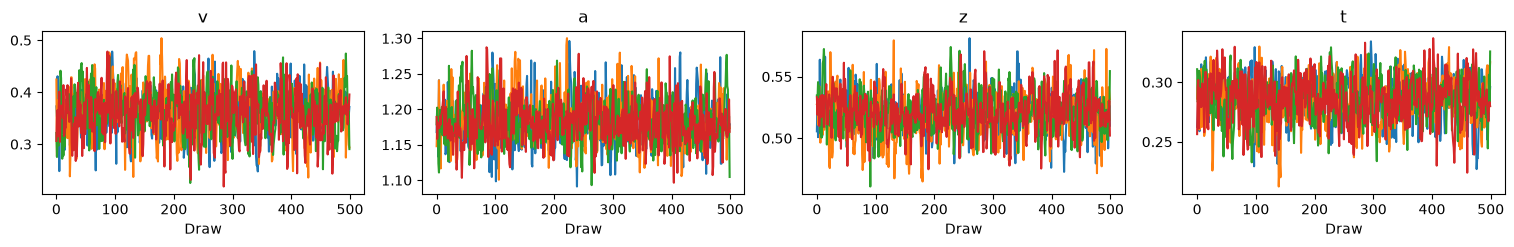

In [12]:
az.plot_trace(idata_nre, var_names=DDM_PARAM_NAMES)
plt.tight_layout()
plt.show()

### Part 5b — Assessment: where does the NRE classifier prefer the observed data?

For NRE the logit `forward(theta, x)` equals `log p(x | θ) − log p(x)` up to a
constant. The θ-independent term cancels when we compare two θ values on the
same data, so the *summed logit over trials* tells us which θ the classifier
finds more consistent with the data. We assess the learned classifier's preference
at the generating value and sampled posterior mean below. This diagnostic does not
establish calibration; the fixed-seed analytical-posterior comparison in Part 6
is a reported diagnostic, not an execution gate.

In [13]:
posterior_mean_nre = {p: float(idata_nre.posterior[p].mean()) for p in DDM_PARAM_NAMES}
obs_x_t = torch.from_numpy(obs_data[["rt", "response"]].values.astype(np.float32))


def total_logit(classifier, theta_dict):
    """Sum log-ratio logit over all observed trials at a single theta."""
    theta_row = torch.tensor(
        [[theta_dict[p] for p in DDM_PARAM_NAMES]], dtype=torch.float32
    ).repeat(len(obs_x_t), 1)
    with torch.no_grad():
        return classifier(theta_row, obs_x_t).sum().item()


lt_true = total_logit(classifier_nre, dict(zip(DDM_PARAM_NAMES, TRUE_THETA)))
lt_mean = total_logit(classifier_nre, posterior_mean_nre)

print(f"NRE total logit at true theta:      {lt_true:+.2f}")
print(f"NRE total logit at posterior mean:  {lt_mean:+.2f}")
print(f"Δ (mean − true):                    {lt_mean - lt_true:+.2f}")
print()
if lt_mean > lt_true + 5.0:
    print(
        "→ NRE prefers the posterior mean over the generating value by a large margin."
    )
    print("  See the numerical analytical-posterior comparison below.")
elif lt_mean > lt_true:
    print("→ NRE mildly prefers the posterior mean over the truth.")
    print("  See the numerical analytical-posterior comparison below.")
else:
    print("→ NRE assigns at least as much logit to the generating value.")
    print("  See the numerical analytical-posterior comparison below.")
print()
print(f"Posterior mean: {posterior_mean_nre}")
print(f"True theta:     {dict(zip(DDM_PARAM_NAMES, TRUE_THETA.tolist()))}")

NRE total logit at true theta:      +128.22
NRE total logit at posterior mean:  +135.73
Δ (mean − true):                    +7.51

→ NRE prefers the posterior mean over the generating value by a large margin.
  See the numerical analytical-posterior comparison below.

Posterior mean: {'v': 0.36334895102235093, 'a': 1.18297469509964, 'z': 0.5203050980173863, 't': 0.2852185139405524}
True theta:     {'v': 0.5, 'a': 1.2000000476837158, 'z': 0.5, 't': 0.25}


## Part 6 — Ground-truth posterior via HSSM's analytical DDM

HSSM ships a closed-form analytical likelihood for the standard DDM
(`loglik_kind="analytical"`, the [Navarro & Fuss](https://psyarxiv.com/cwsbm/)
form). Both fits use the *same observed data* and the exact same
`COMPARISON_MODEL_CONFIG`: all four parameters have Uniform priors with the
same bounds as the NRE training domain. This intentionally changes `t` from
HSSM's default HalfNormal prior to `Uniform(0, 2)` on both sides. Once both
sampler-health gates pass, the remaining posterior differences quantify agreement
with the analytical reference on this one matched, fixed-seed inference problem.

The location and scale criteria below are deliberately diagnostic rather than
execution assertions. A **FAIL** means the export-compatible NRE baseline is not
fidelity-qualified for scientific or production inference.

The NRE fit retains 500 draws per chain; the cheaper analytical reference retains
1,000 to make its split-R-hat estimate more stable. Both use 500 tuning draws, four
chains, and the same `r_hat <= 1.01` health threshold. This asymmetry strengthens
the reference estimate rather than relaxing any criterion.

In [14]:
model_analytical = hssm.HSSM(
    data=obs_data,
    model="ddm",
    model_config=COMPARISON_MODEL_CONFIG,
    loglik_kind="analytical",
    p_outlier=0,
)
with warnings.catch_warnings(record=True) as analytical_sampling_warnings:
    warnings.simplefilter("always")
    idata_analytical = model_analytical.sample(
        sampler="numpyro",
        draws=ANALYTICAL_MCMC_DRAWS,
        tune=MCMC_TUNE,
        chains=MCMC_CHAINS,
        target_accept=0.9,
        progressbar=False,
        nuts={"max_tree_depth": MAX_TREE_DEPTH},
        random_seed=ANALYTICAL_SAMPLING_SEED,
    )
report_captured_warnings("analytical DDM sampling", analytical_sampling_warnings)
summary_analytical = az.summary(
    idata_analytical, var_names=DDM_PARAM_NAMES, kind="all", round_to="none"
)
validate_sampling_health(idata_analytical, summary_analytical, "analytical DDM")
posterior_mean_gap = (summary_nre["mean"] - summary_analytical["mean"]).abs()
combined_posterior_sd = np.hypot(summary_nre["sd"], summary_analytical["sd"])
standardized_mean_gap = posterior_mean_gap / combined_posterior_sd
max_standardized_mean_gap = float(standardized_mean_gap.max())
posterior_sd_ratio = summary_nre["sd"] / summary_analytical["sd"]
sd_ratio_values = np.asarray(posterior_sd_ratio, dtype=float)
min_sd_ratio = float(np.min(sd_ratio_values))
max_sd_ratio = float(np.max(sd_ratio_values))
comparison_summary = pd.concat(
    {
        "sbi NRE": summary_nre[["mean", "sd"]],
        "analytical DDM": summary_analytical[["mean", "sd"]],
    },
    axis=1,
)
agreement_diagnostics = pd.DataFrame(
    {
        "standardized mean gap": standardized_mean_gap,
        "NRE / analytical SD": posterior_sd_ratio,
    }
)
location_status = (
    np.isfinite(max_standardized_mean_gap)
    and max_standardized_mean_gap <= MAX_STANDARDIZED_MEAN_GAP
)
scale_status = bool(
    np.all(np.isfinite(sd_ratio_values))
    and np.all((sd_ratio_values >= MIN_SD_RATIO) & (sd_ratio_values <= MAX_SD_RATIO))
)
agreement_status = location_status and scale_status
print("Posterior summaries:")
print(comparison_summary)
print("\nPer-parameter agreement diagnostics:")
print(agreement_diagnostics)
print(
    "\nDiagnostic criteria: "
    f"max standardized mean gap <= {MAX_STANDARDIZED_MEAN_GAP:.1f}; "
    f"all SD ratios in [{MIN_SD_RATIO:.1f}, {MAX_SD_RATIO:.1f}]"
)
print(
    f"Observed: max standardized mean gap={max_standardized_mean_gap:.2f}; "
    f"SD-ratio range={min_sd_ratio:.2f}–{max_sd_ratio:.2f}"
)
if agreement_status:
    print(
        "Diagnostic status: PASS for this fixed-seed example. This is not "
        "scientific or production qualification."
    )
else:
    print(
        "Diagnostic status: FAIL. This baseline is not fidelity-qualified for "
        "scientific or production inference."
    )
summary_analytical

Model initialized successfully.


Using default initvals. 



NUTS[numpyro]: [z, a, t, v]


analytical DDM sampling warnings:
- `init='adapt_diag'` is ignored by `nuts_sampler='numpyro'`; the external sampler uses its own initialization.
- There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.


analytical DDM: divergences=0, tree-depth hits=0, max r_hat=1.0014, min bulk/tail ESS=2017/2018, min BFMI=0.969
Posterior summaries:
    sbi NRE           analytical DDM          
       mean        sd           mean        sd
v  0.363349  0.043692       0.504333  0.048479
a  1.182975  0.031631       1.231381  0.029705
z  0.520305  0.016774       0.495117  0.016647
t  0.285219  0.018591       0.263850  0.019402

Per-parameter agreement diagnostics:
   standardized mean gap  NRE / analytical SD
v               2.160246             0.901254
a               1.115534             1.064857
z               1.065834             1.007646
t               0.795195             0.958216

Diagnostic criteria: max standardized mean gap <= 1.5; all SD ratios in [0.5, 2.0]
Observed: max standardized mean gap=2.16; SD-ratio range=0.90–1.06
Diagnostic status: FAIL. This baseline is not fidelity-qualified for scientific or production inference.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
v,0.504333,0.048479,0.425030,0.581492,2276.106473,2496.514525,1.001284,0.001016,0.000716
a,1.231381,0.029705,1.184807,1.279974,2366.975227,2690.301828,1.000057,0.000611,0.000437
z,0.495117,0.016647,0.468248,0.522111,2468.242433,2678.830283,1.001447,0.000335,0.000234
t,0.263850,0.019402,0.230933,0.293009,2017.219177,2017.905422,1.000780,0.000436,0.000312


## Part 7 — Posterior comparison: analytical vs sbi NRE

The analytical posterior is the reference for this model + data; the sbi-NRE
marginals are the approximation we built. The NRE fit retains 500 draws per chain,
while the cheaper analytical reference retains 1,000 to stabilize its split-R-hat
estimate; both keep 500 tuning draws and four chains. The executable sampler-health
checks apply the same thresholds to both fits: zero divergences, zero transitions at
the maximum tree depth, split-R-hat at most 1.01, bulk and tail ESS of at least
400, and BFMI of at least 0.30 for both fits. The location criterion (maximum
standardized mean gap 1.5) and scale criterion (all NRE-to-analytical posterior
SD ratios between 0.5 and 2.0) are reported as a diagnostic status; they do not
stop this integration tutorial from executing. A **FAIL** means the baseline is
not fidelity-qualified for scientific or production inference. A **PASS** only
means this fixed-seed dataset meets these illustrative criteria; it is not
calibration or a substitute for broader validation of a production estimator.

This notebook and the [BayesFlow NRE tutorial](../bayesflow_nre_onnx_integration/)
share only `TRUE_THETA`. This sbi example uses 500 observations, infers all four
parameters, uses separate deterministic seeds, and trains under broader priors;
the BayesFlow example uses 100 observations, infers only `v`, and uses narrower
priors. They are not a matched cross-toolkit benchmark.

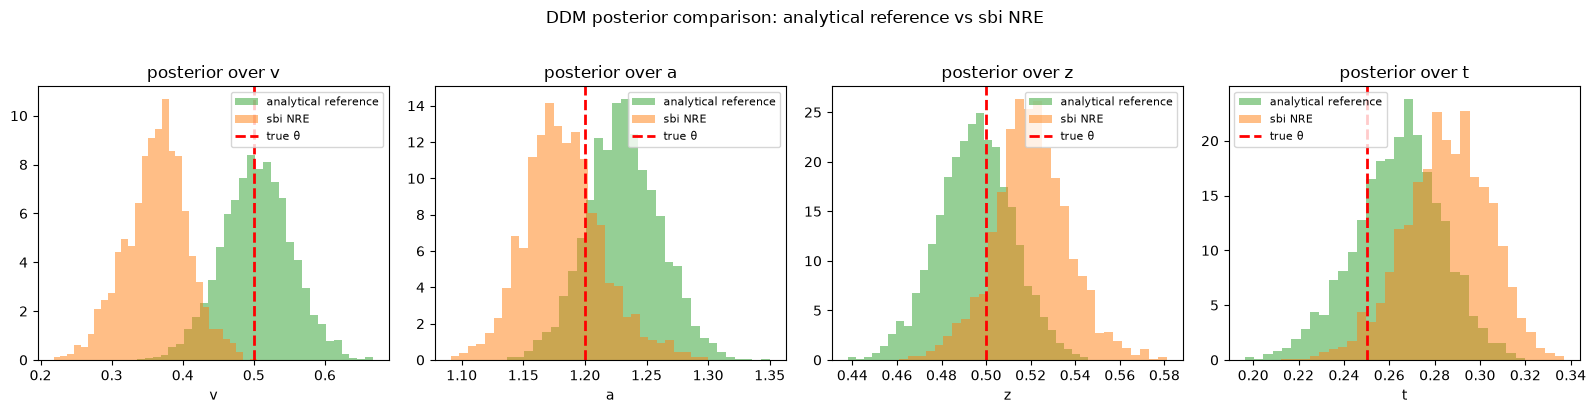

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, name, true_val in zip(axes, DDM_PARAM_NAMES, TRUE_THETA):
    samples_ana = idata_analytical.posterior[name].values.flatten()
    samples_nre = idata_nre.posterior[name].values.flatten()
    ax.hist(
        samples_ana,
        bins=30,
        alpha=0.5,
        label="analytical reference",
        color="C2",
        density=True,
    )
    ax.hist(samples_nre, bins=30, alpha=0.5, label="sbi NRE", color="C1", density=True)
    ax.axvline(true_val, color="red", linestyle="--", linewidth=2, label="true θ")
    ax.set_xlabel(name)
    ax.set_title(f"posterior over {name}")
    ax.legend(fontsize=8)
fig.suptitle("DDM posterior comparison: analytical reference vs sbi NRE", y=1.02)
plt.tight_layout()
plt.show()

## Summary and deferred work

We trained an sbi **NRE_A** classifier on synthetic DDM data — a moderate MLP
(`hidden_features=100`, `norm_layer=nn.Identity` so the graph stays
ONNX-exportable, no embedding net on the parameters) on 1M `(θ, x)` pairs (one
simulation per θ) — exported it to ONNX via
`lanfactory.onnx.transform_sbi_to_onnx`, and ran MCMC through HSSM's existing
`loglik_kind="approx_differentiable"` pipeline. The resulting posterior is
compared against HSSM's analytical DDM posterior on the same data and exact same
Uniform-prior support. This matched analytical fit provides a numerical diagnostic
for the executable integration example, not evidence of calibration.

> A more ambitious configuration — `NRE_B` with atomic contrastive estimation
> (`num_atoms=20`), an `FCEmbedding` on θ, and a larger classifier — collapsed
> to a near-constant log-likelihood (the chains explored the whole prior with no
> concentration). This tutorial uses the simpler, export-compatible `NRE_A`/MLP
> baseline (see Part 3). Sensitivity, export round-trip, and sampler health remain
> hard execution checks. Posterior location and scale agreement are reported rather
> than asserted: a failing result leaves the integration demonstration intact but
> means the baseline is not fidelity-qualified for scientific or production
> inference. Improving that baseline is left as follow-up work.

**Why not NLE in this tutorial?**

We originally planned an NLE section too. Vanilla NLE with a MAF flow produces
qualitatively wrong posteriors on DDM data because rt is continuous but choice
is discrete (∈ {−1, +1}); the flow can't represent that structure or the hard
support boundary `rt > t_nd`. The correct sbi method is **MNLE** (Mixed Neural
Likelihood Estimator), which factorizes `p(rt, choice | θ) = p(choice | θ) ·
p(rt | choice, θ)`. But MNLE's `CategoricalMassEstimator` uses
`torch.searchsorted` for value-to-index lookup, which `torch.onnx.export` does
not support — blocking the ONNX export path until a `SearchSorted` ONNX-op
handler is added to `jaxonnxruntime`. The same gap blocks Neural Spline Flows;
a single ~50-line upstream PR adding that `SearchSorted` handler would unlock
both NSF flows and MNLE in one stroke.

**Where to look next**

- LANfactory's [Exporting sbi Models guide](https://lnccbrown.github.io/LANfactory/exporting_sbi_models/) — supported-architecture matrix, known constraints, troubleshooting.
- The BayesFlow LRE tutorial (`bayesflow_lre_integration.ipynb`) — a related DDM integration with a different SBI library.
- LAN tutorials (`main_tutorial.ipynb`) — the original LANfactory workflow this integration builds on top of.